In [1]:
# =============================================================================
# TMO / tmopy Tutorial – Human PBMC
# =============================================================================
import os
import tmopy as tmo
import scanpy as sc
import matplotlib.pyplot as plt
import random
random.seed(8)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# 1. Setup paths
# ---------------------------------------------------------------------------
h5_file = "./data/10x_pbmc/pbmc_unsorted_3k_filtered_feature_bc_matrix.h5"
atac_annotation_file = "./data/10x_pbmc/pbmc_unsorted_3k_atac_peak_annotation.tsv"
output_dir = "./results/tmo_results_pbmc_tmopy"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# ---------------------------------------------------------------------------
# 2. Load and preprocess
# ---------------------------------------------------------------------------
adata = tmo.pp.read_10x_multiome(h5_file, atac_annotation_file)
print(adata)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from data\10x_pbmc\pbmc_unsorted_3k_filtered_feature_bc_matrix.h5


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:565: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_

AnnData object with n_obs × n_vars = 2825 × 36601
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
    uns: 'atac_annotation_file', 'peak_names'
    obsm: 'ATAC'


C:\Users\phabe\OneDrive\Escritorio\PhD_MUDS\TemporalMultiOmics\tmopy\pp\read.py:56: ImplicitModificationWarning: Setting element `.obsm['ATAC']` of view, initializing view as actual.
  adata_rna.obsm['ATAC'] = adata_atac.X
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# Compute Gene‑level ATAC (peaks -> genes)
adata = tmo.pp.compute_gene_level_atac(adata)
print("Gene-level ATAC matrix shape:", adata.obsm['ATAC_gene'].shape)

Building binary peak‑gene matrix...
M shape: (81156, 26976), non‑zeros: 102702
Peaks matched to genes: 80680/81156 (99.4%)
Computing gene‑activity matrix...
Gene‑activity shape: (2825, 26976), non‑zeros: 16604862
Gene-level ATAC matrix shape: (2825, 26976)


In [5]:
# Compute pseudotime, using Pax6 as early marker to orient the trajectory
adata = tmo.pp.compute_pseudotime(adata, root_marker="CD34")
print(f"Pseudotime range: {adata.obs['pseudotime'].min():.3f} – {adata.obs['pseudotime'].max():.3f}")
print(f"Dataset reversed: {adata.uns.get('pseudotime_reversed', False)}")

Marker CD34 correlates positively (r=0.004); keeping orientation.
Pseudotime range: 0.000 – 1.000
Pseudotime range: 0.000 – 1.000
Dataset reversed: False


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
# ---------------------------------------------------------------------------
# 3. Annotate RNA components with GO terms (internet required)
# ---------------------------------------------------------------------------
component_annotation = tmo.tl.annotate_components(
    adata, n_components=50, n_top_genes=100, n_top_go=5, delay=2.0, organism='human'
)
component_annotation.head()

Running GO enrichment via Enrichr (delay 2.0s between requests)...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [05:46<00:00,  6.93s/it]


,Component,Top_genes,GO_terms
0,Comp0,"PLXDC2, SAT1, ZEB2, SLC8A1, VCAN, LYZ, LYN, FC...",Cytoplasmic Translation (GO:0002181); Peptide ...
1,Comp1,"AFF3, BANK1, CD74, IGHM, HLA-DRA, IGKC, RALGPS...",Antigen Receptor-Mediated Signaling Pathway (G...
2,Comp2,"S100A4, ACTB, TMSB4X, PFN1, CFL1, ACTG1, S100A...",Cytoplasmic Translation (GO:0002181); Peptide ...
3,Comp3,"GNLY, NKG7, CCL5, LEF1, MAML2, PRF1, BACH2, PR...",Cytoplasmic Translation (GO:0002181); Macromol...
4,Comp4,"MT-ND4, MT-ND2, MT-ND3, MT-ATP6, MT-ND1, MT-CO...",Regulation Of Cell-Matrix Adhesion (GO:0001952...


In [7]:
# ---------------------------------------------------------------------------
# 4. Train asymmetric model
#    (automatically saves best checkpoint + pca.pkl, tfidf.pkl, lsi.pkl)
# ---------------------------------------------------------------------------
model = tmo.tl.train_asymmetric(
    adata,
    epochs=50,
    val_interval=5,
    lambda_lag=0.1,
    batch_size=32,
    lr=1e-3,
    device='cpu',          # change to 'cuda' if GPU available
    save_model=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 7.5474  lag 0.0047  LCS 0.7524
  -> Best model saved (LCS=0.7524)
Epoch  5 | recon 0.1561  lag 0.0001  LCS 0.9717
  -> Best model saved (LCS=0.9717)
Epoch 10 | recon 0.0570  lag 0.0001  LCS 0.9856
  -> Best model saved (LCS=0.9856)
Epoch 15 | recon 0.0409  lag 0.0001  LCS 0.9799
Epoch 20 | recon 0.0361  lag 0.0000  LCS 0.9907
  -> Best model saved (LCS=0.9907)
Epoch 25 | recon 0.0196  lag 0.0000  LCS 0.9940
  -> Best model saved (LCS=0.9940)
Epoch 30 | recon 0.0191  lag 0.0001  LCS 0.9853
Epoch 35 | recon 0.0162  lag 0.0001  LCS 0.9940
Epoch 40 | recon 0.0155  lag 0.0000  LCS 0.9930
Epoch 45 | recon 0.0130  lag 0.0000  LCS 0.9953
  -> Best model saved (LCS=0.9953)
Epoch 50 | recon 0.0133  lag 0.0000  LCS 0.9958
  -> Best model saved (LCS=0.9958)
Training finished. Best LCS: 0.9958


In [8]:
# ---------------------------------------------------------------------------
# (Optional) Train symmetric baseline for comparison
# ---------------------------------------------------------------------------
sym_model = tmo.tl.train_symmetric(
    adata,
    epochs=50,
    val_interval=5,
    batch_size=32,
    lr=1e-3,
    device='cpu',
    save_model=os.path.join(output_dir, "tmo_symmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 7.8853  LCS 0.1693
  -> Best model saved (LCS=0.1693)
Epoch  5 | recon 0.1325  LCS 0.1833
  -> Best model saved (LCS=0.1833)
Epoch 10 | recon 0.0486  LCS 0.1815
Epoch 15 | recon 0.0351  LCS 0.1875
  -> Best model saved (LCS=0.1875)
Epoch 20 | recon 0.0249  LCS 0.1962
  -> Best model saved (LCS=0.1962)
Epoch 25 | recon 0.0177  LCS 0.1918
Epoch 30 | recon 0.0158  LCS 0.1952
Epoch 35 | recon 0.0145  LCS 0.1954
Epoch 40 | recon 0.0151  LCS 0.1938
Epoch 45 | recon 0.0117  LCS 0.1934
Epoch 50 | recon 0.0109  LCS 0.1962
Training finished. Best LCS: 0.1962


In [6]:
# ---------------------------------------------------------------------------
# 5. Evaluate asymmetric model -> Δτ heatmap (Figure 1)
# ---------------------------------------------------------------------------
delta_tau, pt_grid, lcs, row_labels = tmo.tl.evaluate_asymmetric(
    adata,
    model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    n_components=50,
    cluster_aggregate=True,
    dist_threshold=1.0,
    standardize=True
)
print(f"Lag Concordance Score (LCS): {lcs:.4f}")

Dataset not reversed; Δτ signs kept as computed.
LCS (raw, for validation) = 0.2126
Retained 48 / 50 components for clustering (2 removed due to constant / NaN profiles).
Standardized Δτ profiles for clustering.
Number of clusters at threshold 1.0: 13
Lag Concordance Score (LCS): 0.2126


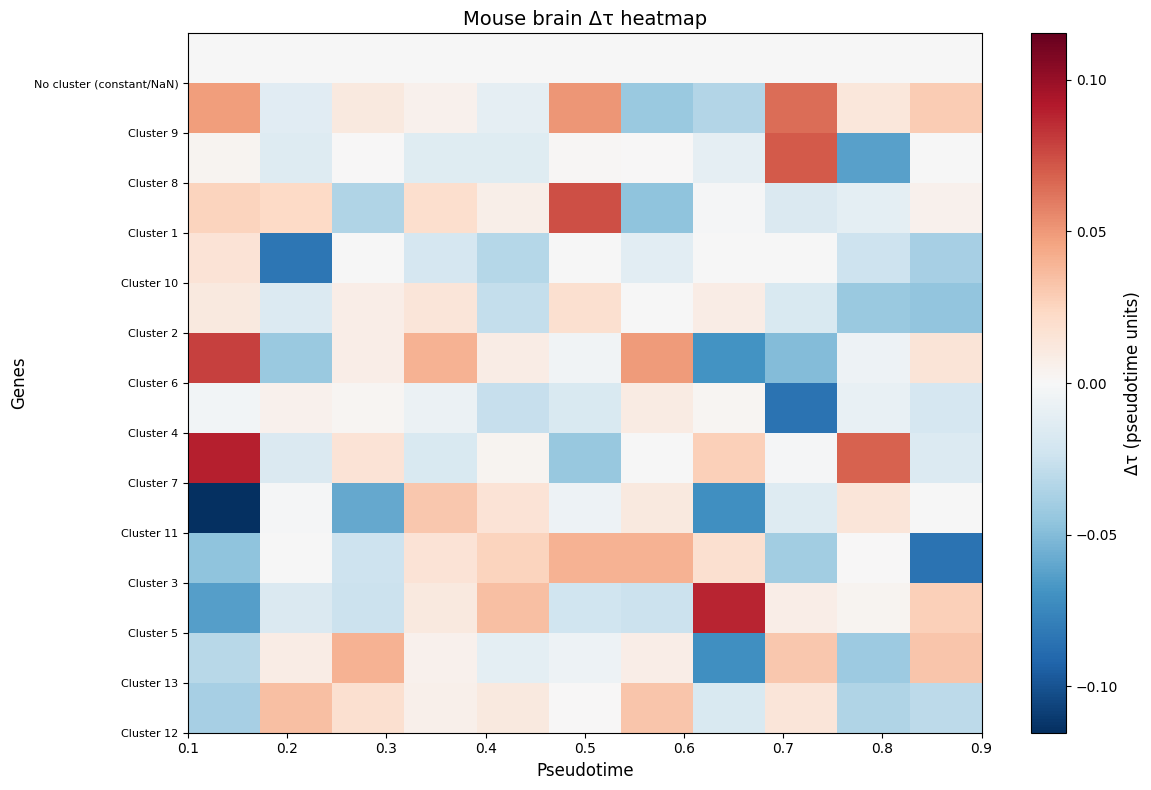

In [7]:
# Plot heatmap
fig1 = tmo.pl.plot_delta_tau(
    delta_tau,
    pt_grid,
    row_labels,
    title="Mouse brain Δτ heatmap",
    save=os.path.join(output_dir, "fig1_delta_tau.pdf"),
    show=False
)
plt.show()
plt.close(fig1)

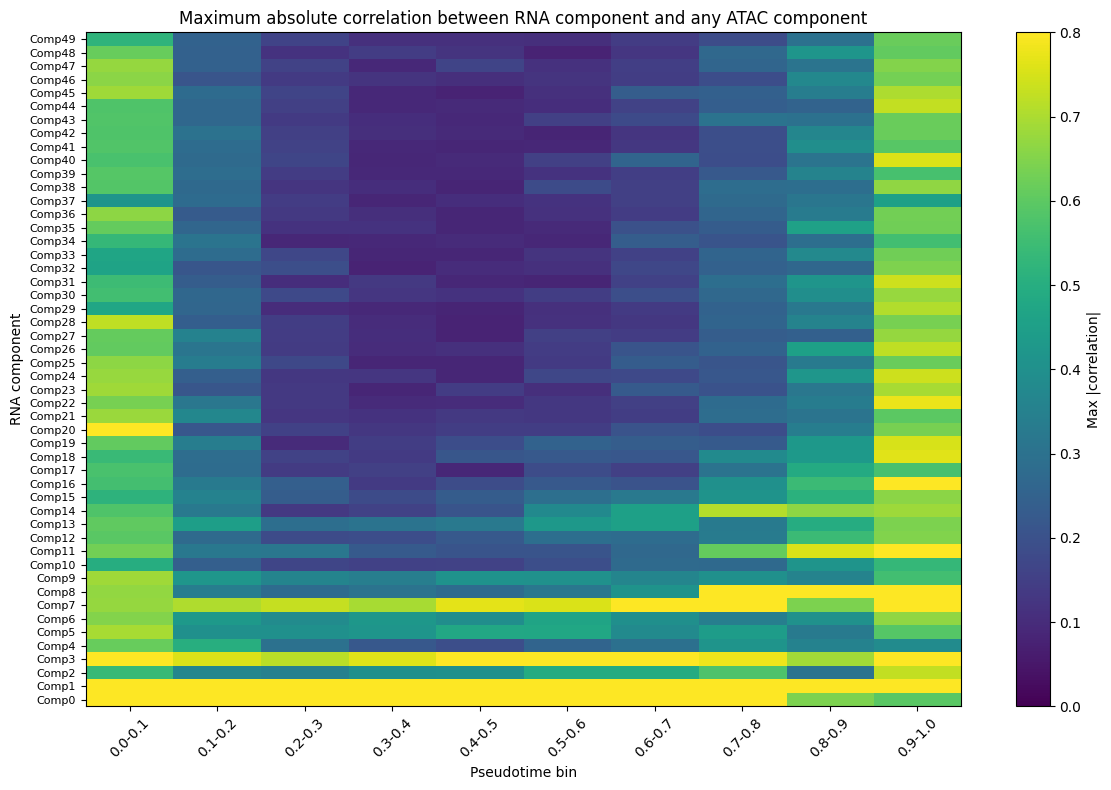

In [8]:
# ---------------------------------------------------------------------------
# 6. ATAC‑RNA correlation heatmap (Figure 2)
# ---------------------------------------------------------------------------
fig2 = tmo.pl.plot_correlation(
    adata,
    n_bins=10,
    save=os.path.join(output_dir, "fig2_correlation.pdf"),
    show=False
)
plt.show()
plt.close(fig2)


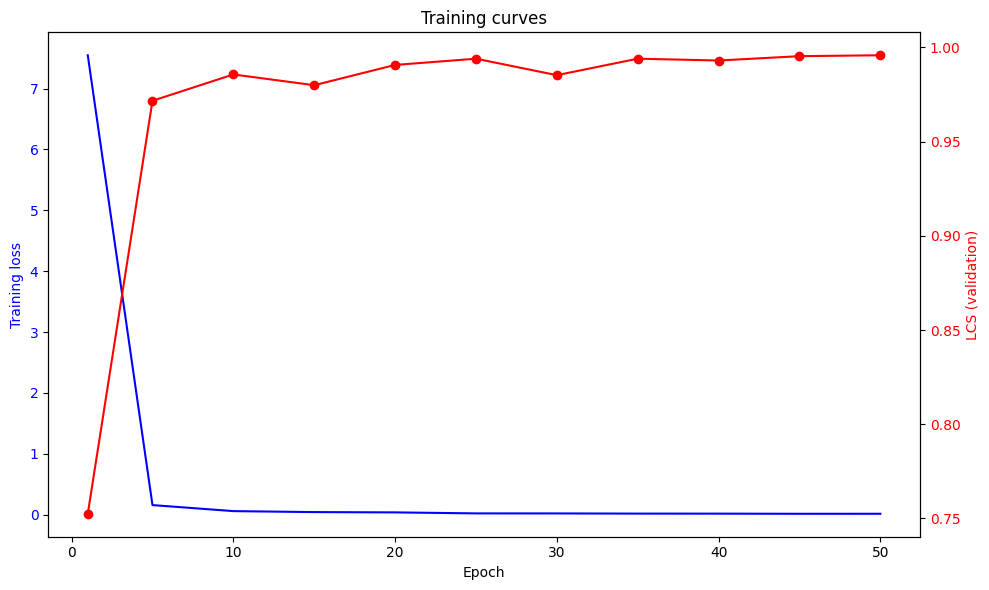

In [10]:
# ---------------------------------------------------------------------------
# 7. Plot training curves (Figure 3)
#    The training script saved a CSV file in the output directory.
# ---------------------------------------------------------------------------
metrics_csv = os.path.join(output_dir, "training_metrics_tmo_asymmetric.csv")
if os.path.exists(metrics_csv):
    fig3 = tmo.pl.plot_training_curves(
        metrics_csv,
        save=os.path.join(output_dir, "fig3_training_curves.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig3)
else:
    print("Training metrics CSV not found; please adjust path.")


In [11]:
# ---------------------------------------------------------------------------
# 8. ChIP‑seq validation for PAX5  (two‑sided)
# ---------------------------------------------------------------------------
target_file = "./data/10x_pbmc/PAX5_top500_genes.txt"
if os.path.exists(target_file):
    print("Running ChIP‑seq validation for PAX5...")
    # Pre‑fitted transformers are saved automatically by train_asymmetric,
    # but for a quick run you can omit them; the function will still work.
    chip_res = tmo.tl.validate_chipseq(
        adata,
        model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
        target_genes_file=target_file,
        match_expression=True,
        n_components=50,
        alternative='two-sided',
        pca=os.path.join(output_dir,"pca.pkl"),   # optional, for exact reproducibility
        tfidf=os.path.join(output_dir,"tfidf.pkl"),
        lsi=os.path.join(output_dir,"lsi.pkl")
    )
    print(f"ChIP‑seq validation p‑value: {chip_res['p_value']:.4e}")
    print(f"Target Δτ mean: {chip_res['mean_target']:.6f}, background Δτ mean: {chip_res['mean_background']:.6f}")
else:
    print(f"Target gene file {target_file} not found. Skipping ChIP‑seq validation.")

Running ChIP‑seq validation for PAX5...
Target genes found: 482
Expression‑matched background genes: 482

=== CCF‑based Δτ validation ===
Target Δτ mean: -0.014283, background Δτ mean: -0.010794
Mann‑Whitney U: 90094.0, p = 1.5240e-09
ChIP‑seq validation p‑value: 1.5240e-09
Target Δτ mean: -0.014283, background Δτ mean: -0.010794


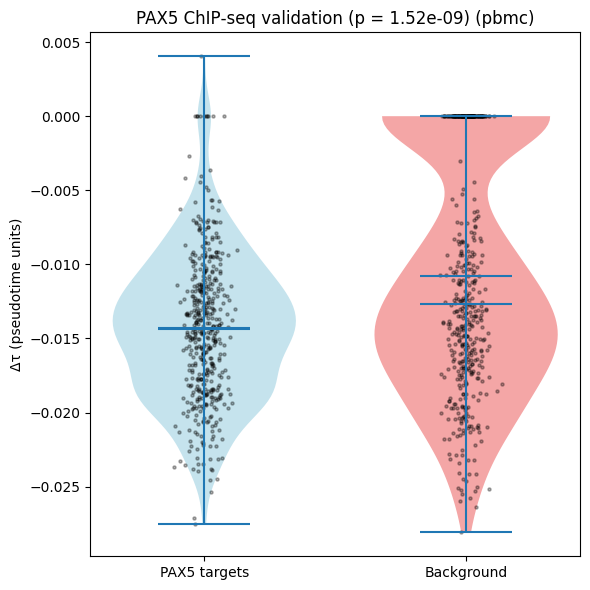

ChIP‑seq validation figure saved to fig4_chipseq_PAX5.pdf


In [12]:
# ---------------------------------------------------------------------------
# 9. Violin plot for ChIP‑seq
# ---------------------------------------------------------------------------
if 'chip_res' in locals() and chip_res['p_value']:
    p_val = chip_res['p_value']
    fig4 = tmo.pl.plot_violin_validation(
        chip_res['target_lags'], chip_res['background_lags'],
        target_label="PAX5 targets",
        background_label="Background",
        title=f"PAX5 ChIP‑seq validation (p = {p_val:.2e}) (pbmc)",
        ylabel="Δτ (pseudotime units)",
        save=os.path.join(output_dir, "fig4_chipseq_PAX5.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig4)
    print("ChIP‑seq validation figure saved to fig4_chipseq_PAX5.pdf")
else:
    print("Run ChIP-seq validation first, to compute p-values.")

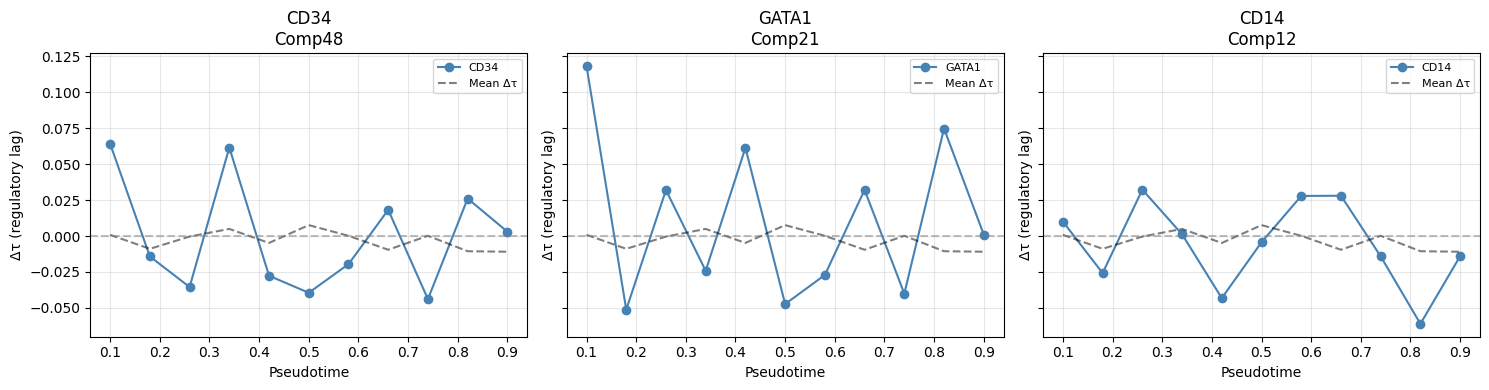

In [13]:
# ---------------------------------------------------------------------------
# (Optional) Marker gene Δτ profiles
# ---------------------------------------------------------------------------
fig_markers = tmo.pl.plot_marker_profiles(
    adata,
    marker_genes=["CD34", "GATA1", "CD14"],
    save=os.path.join(output_dir, "marker_profiles.pdf"),
    show=False
)
plt.show()
plt.close(fig_markers)

In [14]:
# ---------------------------------------------------------------------------
# 10. Summary
# ---------------------------------------------------------------------------
print("\nAnalysis completed. Results saved in:", output_dir)
print("Figure 1: Δτ heatmap (fig1_delta_tau.pdf)")
print("Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)")
print("Figure 3: Training curves (fig3_training_curves.pdf)")


Analysis completed. Results saved in: ./results/tmo_results_pbmc_tmopy
Figure 1: Δτ heatmap (fig1_delta_tau.pdf)
Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)
Figure 3: Training curves (fig3_training_curves.pdf)
